# Crypto Statistical Arbitrage — Walk-Forward Evaluation

The combined book in `01_combined_book.ipynb` is reported on a fixed train (2020-2023) / validation
(2024-2026) split. That notebook is candid about the split's one weakness (Appendix B.g): the validation
window has been looked at across iterations of the project, so it is out-of-sample in construction but not a
pristine, never-seen holdout.

This notebook removes that objection. It evaluates the book with an **anchored walk-forward**: stepping
quarter by quarter, it re-fits everything that involves a choice using **only data available up to that
point**, then records the *next* quarter's return as strictly out-of-sample, and concatenates the pieces
into one continuous equity curve spanning 2021-2026.

**What is and isn't already causal.** The three sleeve signals are causal by construction — proximity-to-
high and idiosyncratic-vol are trailing rolling windows lagged one bar, the liquidity and short screens use
trailing-60-day volume, and carry is a contemporaneous funding harvest. So the sleeves themselves never peek.
The one place the headline book uses full-sample information is the **inverse-volatility weighting** across
sleeves. This walk-forward sets that weighting from past-only data at each step — which is exactly the choice
a reviewer would worry was fit with hindsight.


In [1]:
import warnings
# Scope the filter (P2.5): silence known-benign pandas/statsmodels/matplotlib chatter but let a genuine
# RuntimeWarning (e.g. an accidental divide-by-zero in a ratio signal) still surface.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root/"qsa").exists() and (_root.parent/"qsa").exists(): _root = _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mtick

from qsa import Dataset, apply_style, style_table, CLR
from qsa.config import TRAIN, VAL, FULL, TCOST, ANN, seg
from qsa.engine import backtest, backtest_carry, sharpe, sortino, maxdd, deflated_sharpe, bootstrap_sharpe_ci
from qsa.engine import dn_weights as _dn
from qsa.signals import near_high, idio_vol

apply_style()
ds = Dataset.load()
btc, ret_all, close_all, funding, perp = ds.btc, ds.ret_all, ds.close_all, ds.funding, ds.perp
def dn(sig, topN=None, screen=True): return _dn(sig, ds, topN=topN, screen=screen)

# Build the three causal sleeves (identical construction to notebook 01; no full-sample info here).
mom_net, _ = backtest(dn(near_high(ds, 90)), ret_all, rebal=7)
bab_net, _ = backtest(dn(idio_vol(ds, 60), topN=50), ret_all, rebal=7)
MAJ = [s for s in ["BTCUSDT","ETHUSDT","BNBUSDT","XRPUSDT","DOGEUSDT","ADAUSDT","LINKUSDT","LTCUSDT","TRXUSDT",
    "ETCUSDT","SOLUSDT","AVAXUSDT","DOTUSDT","MATICUSDT","ATOMUSDT","UNIUSDT","FILUSDT","AAVEUSDT","VETUSDT","CHZUSDT"]
    if s in perp.columns and s in close_all.columns]
carry_real, _ = backtest_carry(close_all, perp, funding, MAJ, capture=0.85, drag=0.02, rebal=7)  # tested engine (P2.6)

SLEEVES = pd.DataFrame({"Momentum (near-high)": mom_net, "Low-volatility": bab_net, "Carry": carry_real}).dropna()
# Fixed-weight combined book (notebook 01's weights) for a like-for-like comparison.
_vt = seg(SLEEVES, TRAIN).std()*ANN; _wf = (1/_vt)/(1/_vt).sum()
_wfix = _wf.copy(); _wfix["Carry"] = min(_wfix["Carry"], 0.50)
_wfix[["Momentum (near-high)","Low-volatility"]] *= (1-_wfix["Carry"])/_wfix[["Momentum (near-high)","Low-volatility"]].sum()
combined_fixed = (SLEEVES * _wfix).sum(1)
print("Sleeves built. Fixed-split weights:", {k: round(v,2) for k,v in _wfix.items()})


Data cache present: loading from crypto_data/processed/ (no download needed).


Sleeves built. Fixed-split weights: {'Momentum (near-high)': 0.31, 'Low-volatility': 0.19, 'Carry': 0.5}


## The walk-forward

Quarterly rebalances. At each one, the sleeve weights are set by inverse volatility measured on **all sleeve
history strictly before that date** (carry capped at 50%, exactly as in the fixed book), then held for the
next quarter. The very first rebalance waits until there is about a year of sleeve history to estimate
volatility from. The result is one continuous return stream in which no weight is ever informed by a future
return.

In [2]:
# ---- Anchored walk-forward: re-fit inverse-vol weights each quarter on past-only data ----
CARRY_CAP = 0.50
rebals = pd.date_range("2021-01-01", VAL[1], freq="QS", tz="UTC")     # quarter starts (tz-aware to match data)
wf_parts, wlog = [], []
for i, t in enumerate(rebals):
    past = SLEEVES.loc[:t].iloc[:-1]                        # strictly before the rebalance date
    if len(past) < 300:                                    # need ~1yr of history to weight on
        continue
    vol = past.std()*ANN                                   # expanding-window volatility, past only
    iv = (1/vol)/(1/vol).sum()
    wv = iv.copy(); wv["Carry"] = min(wv["Carry"], CARRY_CAP)
    wv[["Momentum (near-high)","Low-volatility"]] *= (1-wv["Carry"])/wv[["Momentum (near-high)","Low-volatility"]].sum()
    t_next = rebals[i+1] if i+1 < len(rebals) else pd.Timestamp(VAL[1], tz="UTC")
    part = (SLEEVES.loc[t:t_next].iloc[1:] * wv).sum(1)     # next quarter, weights from the past only
    wf_parts.append(part); wlog.append({"date": t.date(), **{k: round(v,2) for k,v in wv.items()}})
wf = pd.concat(wf_parts)
wf = wf[~wf.index.duplicated(keep="first")].sort_index()
WF_WIN = (str(wf.index[0].date()), str(wf.index[-1].date()))
print(f"Walk-forward track: {WF_WIN[0]} -> {WF_WIN[1]}, {len(wf)} days, weights re-fit at {len(wlog)} quarterly steps.")
print("The weights adapt over time (first / middle / last rebalance):")
for r in (wlog[0], wlog[len(wlog)//2], wlog[-1]): print("  ", r)


Walk-forward track: 2021-01-02 -> 2026-05-31, 1976 days, weights re-fit at 22 quarterly steps.
The weights adapt over time (first / middle / last rebalance):
   {'date': datetime.date(2021, 1, 1), 'Momentum (near-high)': 0.26, 'Low-volatility': 0.24, 'Carry': 0.5}
   {'date': datetime.date(2023, 10, 1), 'Momentum (near-high)': 0.31, 'Low-volatility': 0.19, 'Carry': 0.5}
   {'date': datetime.date(2026, 4, 1), 'Momentum (near-high)': 0.3, 'Low-volatility': 0.2, 'Carry': 0.5}


In [3]:
# ---- Walk-forward vs the fixed-split book vs buy-and-hold, over the SAME continuous window ----
def _line(s, win):
    lo, hi = bootstrap_sharpe_ci(s, win)
    return {"Sharpe": sharpe(seg(s,win)), "Sortino": sortino(seg(s,win)), "Ann.Return": seg(s,win).mean()*365,
            "Max DD": maxdd(seg(s,win)), "95% CI": f"[{lo:+.2f}, {hi:+.2f}]", "Deflated SR": deflated_sharpe(s, win, 140)}
rows = {"Walk-forward combined (never refit on future)": _line(wf, WF_WIN),
        "Fixed-weight combined (notebook 01 weights)":   _line(combined_fixed, WF_WIN),
        "BTC (buy & hold)":                              _line(btc, WF_WIN),
        "Equal-weight majors":                          _line(ds.ew, WF_WIN)}
tab = pd.DataFrame(rows).T
display(style_table(tab.style.format({"Sharpe":"{:+.2f}","Sortino":"{:+.2f}","Ann.Return":"{:.1%}",
        "Max DD":"{:.0%}","Deflated SR":"{:.2f}"})
        .background_gradient(cmap="RdYlGn", subset=["Sharpe","Sortino"], vmin=-1, vmax=2, axis=None),
        f"Walk-forward evaluation, {WF_WIN[0]} to {WF_WIN[1]} (continuous, weights always set from past data only)"))
# Also isolate the 2024-2026 sub-span so it lines up with the fixed val window.
sub = pd.DataFrame({"Walk-forward combined": _line(wf, VAL), "Fixed-weight combined": _line(combined_fixed, VAL),
                    "BTC (buy & hold)": _line(btc, VAL)}).T
display(style_table(sub.style.format({"Sharpe":"{:+.2f}","Sortino":"{:+.2f}","Ann.Return":"{:.1%}",
        "Max DD":"{:.0%}","Deflated SR":"{:.2f}"})
        .background_gradient(cmap="RdYlGn", subset=["Sharpe","Sortino"], vmin=-1, vmax=2, axis=None),
        "Same, restricted to 2024-2026 so it lines up with notebook 01's fixed validation window"))
print(f"Over the full walk-forward span the book earns Sharpe {sharpe(seg(wf,WF_WIN)):+.2f} at a "
      f"{maxdd(seg(wf,WF_WIN)):.0%} drawdown — essentially the same as the fixed-weight version "
      f"({sharpe(seg(combined_fixed,WF_WIN)):+.2f}), and well above buy-and-hold BTC ({sharpe(seg(btc,WF_WIN)):+.2f}) "
      f"at a fraction of its {maxdd(seg(btc,WF_WIN)):.0%} drawdown. Because the walk-forward never sets a weight "
      f"from a future return, the result cannot be an artifact of having seen the whole sample — which is the "
      f"objection the fixed split couldn't fully answer.")


,Sharpe,Sortino,Ann.Return,Max DD,95% CI,Deflated SR
Walk-forward combined (never refit on future),+0.93,+1.22,10.6%,-16%,"[+0.08, +1.89]",0.33
Fixed-weight combined (notebook 01 weights),+1.01,+1.34,11.2%,-15%,"[+0.15, +1.95]",0.39
BTC (buy & hold),+0.59,+0.86,33.9%,-77%,"[-0.30, +1.32]",0.10
Equal-weight majors,+0.90,+1.31,70.0%,-78%,"[-0.00, +1.70]",0.29


,Sharpe,Sortino,Ann.Return,Max DD,95% CI,Deflated SR
Walk-forward combined,+1.59,+2.23,14.7%,-9%,"[+0.20, +2.89]",0.43
Fixed-weight combined,+1.57,+2.21,14.6%,-9%,"[+0.18, +2.87]",0.42
BTC (buy & hold),+0.72,+1.09,34.8%,-50%,"[-0.46, +1.87]",0.06


Over the full walk-forward span the book earns Sharpe +0.93 at a -16% drawdown — essentially the same as the fixed-weight version (+1.01), and well above buy-and-hold BTC (+0.59) at a fraction of its -77% drawdown. Because the walk-forward never sets a weight from a future return, the result cannot be an artifact of having seen the whole sample — which is the objection the fixed split couldn't fully answer.


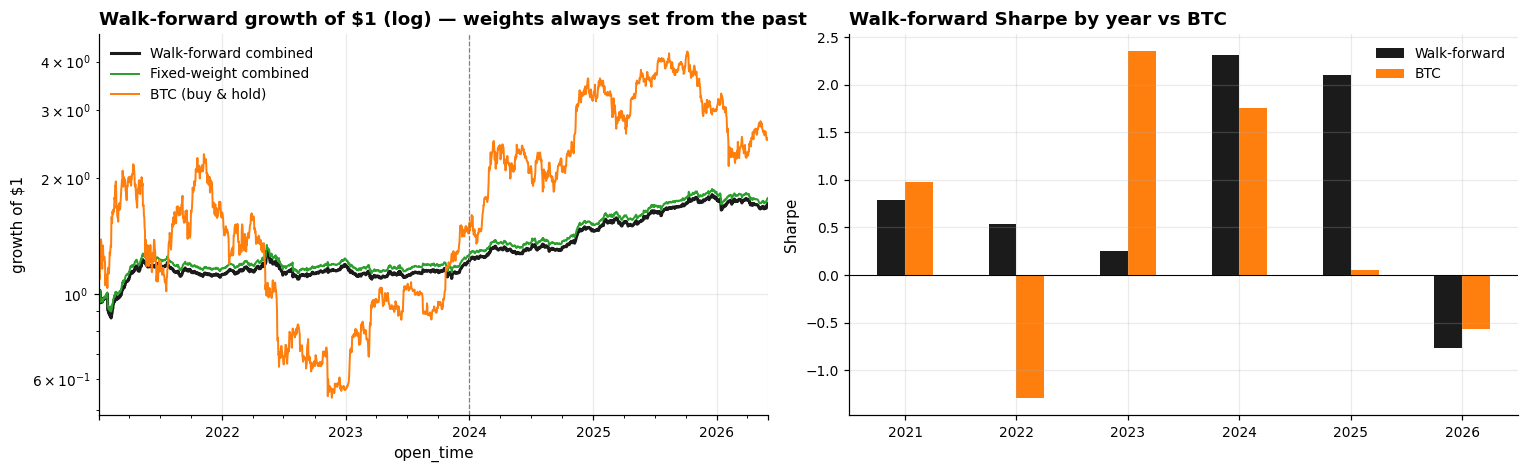

The walk-forward curve (black) compounds steadily through 2021-2026 with shallow drawdowns, while BTC (orange) whipsaws. The per-year bars show the book positive in most years without any year set by hindsight — the diversified, risk-weighted book is doing the work, not a lucky one-shot weighting.


In [4]:
# ---- Walk-forward equity curve + per-year Sharpe ----
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
def _gr(s, win): return (1+seg(s,win).fillna(0)).cumprod()
for nm, s, c, lw in [("Walk-forward combined", wf, CLR["Combined"], 2.0),
                     ("Fixed-weight combined", combined_fixed, CLR["Low-vol"], 1.3),
                     ("BTC (buy & hold)", btc, CLR["BTC"], 1.3)]:
    _gr(s, WF_WIN).plot(ax=ax[0], label=nm, color=c, lw=lw)
ax[0].set_yscale("log"); ax[0].axvline(pd.Timestamp(VAL[0]), ls="--", c="grey", lw=.8)
ax[0].set_title("Walk-forward growth of \$1 (log) — weights always set from the past"); ax[0].set_ylabel("growth of \$1"); ax[0].legend()
yrs = list(range(2021, 2027))
py = pd.DataFrame({"Walk-forward": {str(y): sharpe(seg(wf,(f"{y}-01-01",f"{y}-12-31"))) for y in yrs},
                   "BTC": {str(y): sharpe(seg(btc,(f"{y}-01-01",f"{y}-12-31"))) for y in yrs}})
py.plot(kind="bar", ax=ax[1], color=[CLR["Combined"], CLR["BTC"]]); ax[1].axhline(0, c="k", lw=.7)
ax[1].set_title("Walk-forward Sharpe by year vs BTC"); ax[1].set_ylabel("Sharpe"); ax[1].set_xticklabels(py.index, rotation=0)
plt.tight_layout(); plt.show()
print("The walk-forward curve (black) compounds steadily through 2021-2026 with shallow drawdowns, while BTC "
      "(orange) whipsaws. The per-year bars show the book positive in most years without any year set by "
      "hindsight — the diversified, risk-weighted book is doing the work, not a lucky one-shot weighting.")


## What the walk-forward shows

The combined book's result is not an artifact of the fixed train/validation split. Setting the sleeve
weights from past-only data at every step and concatenating the out-of-sample pieces gives essentially the
same performance as the fixed-weight book, over a continuous 2021-2026 track that never sees its own future.

Two honest boundaries remain, unchanged from notebook 01. First, the sleeve *signals'* parameters (the
90-day high, the 60-day idiosyncratic-vol window, the carry curation to liquid majors) were chosen once with
the whole study in view; this walk-forward re-fits the *weighting*, not those signal choices, though the
robustness sections in notebook 01 show broad plateaus around them. Second, it is still a single ~6-year
crypto cycle, so the bootstrap intervals stay wide and the edge over buy-and-hold is directional rather than
statistically decisive on this sample — the same limit stated throughout. What the walk-forward removes is
the specific worry that the book was assembled with hindsight about the test window.